# BrushCue Example: Indie Sleaze Filter

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/indie_sleaze_filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/indie-sleaze-filter

In [ ]:
!pip install brushcue

[wgpu] using backend Vulkan — adapter 'NVIDIA GeForce RTX 5070' (DiscreteGpu), driver 'NVIDIA'


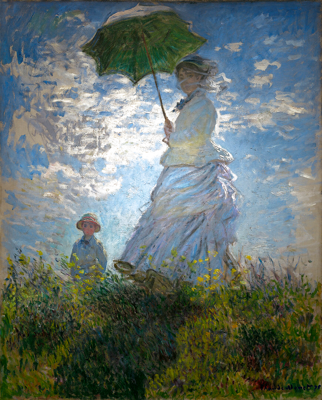

In [1]:
import io
from PIL import Image

import brushcue as bc

input_image = bc.Composition.monet_women_with_parasol()
strength = 1.0
bounds = input_image.bounds()
flashed = input_image.spacial_effect_shader(
    "let col = sample(position);\nlet uv = (position - origin) / size;\nlet d = (uv - vec2<f32>(0.5, 0.45)) * vec2<f32>(size.x / size.y, 1.0);\nlet flash = 1.0 / (1.0 + 9.0 * dot(d, d));\nvar l = col.x;\nlet lo = 1.0 - smoothstep(0.12, 0.5, l);\nl = l * mix(1.0, 0.62 + 0.55 * flash, amount);\nl = l - 0.1 * (1.0 - flash) * lo * amount;\nl = l + 0.14 * smoothstep(0.68, 0.9, l) * amount;\nlet s_curve = l * l * (3.0 - 2.0 * l);\nl = mix(l, s_curve, 0.35 * amount);\nlet hi = smoothstep(0.65, 0.95, l);\nlet n1 = hash(position + seed) - 0.5;\nlet n2 = hash(position * 1.3 + seed + 17.0) - 0.5;\nlet n3 = hash(position * 0.7 + seed + 41.0) - 0.5;\nl = l + n3 * 0.035 * (0.4 + lo) * amount;\nlet a = col.y * (1.0 - 0.35 * hi * amount) + (-0.035 * lo * (1.0 - 0.5 * flash) + n1 * 0.03 * lo) * amount;\nlet b = col.z * (1.0 - 0.35 * hi * amount) + (0.04 * lo * (1.0 - 0.5 * flash) - 0.008 * hi + n2 * 0.03 * lo) * amount;\nlet clipped = clamp(l, 0.0, 1.0);\nlet rolloff = 1.0 - smoothstep(0.9, 1.0, l);\nreturn vec4<f32>(clipped, a * rolloff, b * rolloff, col.w);",
    "fn hash(p: vec2<f32>) -> f32 {\n  return fract(sin(dot(p, vec2<f32>(127.1, 311.7))) * 43758.5453);\n}",
    0.0,
    bc.Dictionary.create()
    .add("amount", strength)
    .add("seed", 3.0)
    .add("origin", bc.Vector2f.from_components(bounds.min_x(), bounds.min_y()))
    .add("size", bc.Vector2f.from_components(bounds.width(), bounds.height())),
    bc.ColorRepresentation.oklab_a(),
)
processed = flashed.saturation_adjust((1.0 + (0.15 * strength))).sharpen(
    1.0, (0.8 * strength)
)
graph = processed.crop(bounds)

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
